# Pool-based Multilabel Active Learning - Getting Started

This notebook introduces a compact multilabel active learning workflow with
`scikit-activeml`. We use BirdSet embeddings as a realistic feature pool, but
the focus stays on the workflow itself: how multilabel targets are
represented, how a classifier and query strategies are connected, and how to
read the resulting learning curves.

You will learn:
- how to prepare BirdSet embeddings and multilabel targets for
  `scikit-activeml`,
- how `MISSING_LABEL` represents unknown labels in the unlabeled pool,
- how to compare task-agnostic and multilabel-specific query strategies in
  one active-learning loop,
- how to read the result plot and the final metric summary, including the
  caveats of multilabel metrics on a sparsely labeled data set.

> **_Google Colab Note:_** If the notebook fails to run after
> installing the needed packages, try to restart the runtime (Ctrl + M) under
> Runtime -> Restart session.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](<colab_link>)

**Notebook Dependencies**

Uncomment the following cell to install all dependencies for this tutorial.

**Data and runtime:** the notebook reuses an existing `BirdSet_BASEAL`
directory or downloads the official archive (about 215 MiB, 303 MB extracted)
from the [Zenodo record](https://zenodo.org/records/19340660) when the data is
missing. Only the `HSN_BASEAL` subset (69 MB) is used below. A complete run
takes about two minutes on a GPU.

**Citation:** the bundled exports are derived from BirdSet and were embedded
with `Perch v2`. If you use this data, cite BirdSet, cite the Perch 2.0
model/paper, and acknowledge the upstream source record listed in the
subset's `metadata.csv`.

In [1]:
# !pip install scikit-activeml[opt] torch tqdm

## General

In multilabel classification, each sample is associated with a binary
indicator vector such as `[1, 0, 1, 0, ...]` because several classes may be
active at the same time.

`scikit-activeml` does not guess this structure. Classifiers and query
strategies receive `target_type="multi-label"` together with a per-output
class vocabulary `classes=[[0, 1], ..., [0, 1]]`, i.e. every target dimension
is its own binary label. Two rules follow from the resolved target semantics
and hold throughout this notebook:

- a row of `y` is either **fully** labeled or **fully** unlabeled, i.e. a
  partially annotated sample is not representable,
- unknown rows are filled with `MISSING_LABEL` and count as one unlabeled
  sample, not as `n_classes` unlabeled entries.

Details on target resolution are documented in
[Target and Annotation Semantics](https://scikit-activeml.github.io/latest/target_semantics.html).

Inside the active-learning loop, we keep two versions of the pool labels:
- `Y_train`: the full multilabel targets, which act as the oracle,
- `Y_known`: the currently revealed labels, where unknown rows are stored as
  `MISSING_LABEL`.

Each cycle follows the same pattern: fit on the currently known labels, query
the next batch, reveal the true labels for that batch, refit the classifier,
and evaluate on a fixed assessment split.

## Imports and Runtime Setup

The imports below show the core pieces of the tutorial: BirdSet data loading,
multilabel metrics, a `SkorchClassifier`, and five pool-based query
strategies.

In [2]:
import csv
import json
import warnings
import urllib.request
import zipfile
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, f1_score

from skactiveml.classifier import SkorchClassifier, SklearnClassifier
from skactiveml.pool import (
    CoreSet,
    LabelCardinalityInconsistency,
    MaxLossReductionMaxConfidence,
    RandomSampling,
    SubSamplingWrapper,
    UHerding,
)
from skactiveml.utils import MISSING_LABEL, call_func, is_labeled

from skorch.callbacks import LRScheduler
from torch import nn
from torch.optim.lr_scheduler import CosineAnnealingLR

warnings.filterwarnings("ignore")
mpl.rcParams["figure.facecolor"] = "white"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Configuration

These are the few parameters worth changing first:
- `DATA_ROOT` points to an existing BirdSet export if you already have one,
- `DATASET_NAME` selects one multilabel pool (`HSN_BASEAL`, `POW_BASEAL`, or
  `UHH_BASEAL`),
- `ASSESSMENT_SPLIT` names the held-out split; the bundled exports provide
  `train` and `validation` only,
- `INITIAL_LABELS`, `QUERY_BATCH_SIZE`, and `N_CYCLES` define the annotation
  budget,
- `SELECTED_STRATEGIES` lets you swap query strategies without touching the
  loop.

In [3]:
REPO_ROOT = Path.cwd()
DATA_ROOT = REPO_ROOT / "BirdSet_BASEAL"
DATASET_NAME = "HSN_BASEAL"
ASSESSMENT_SPLIT = "validation"

INITIAL_LABELS = 150
QUERY_BATCH_SIZE = 75
N_CYCLES = 8
N_REPETITIONS = 5
BASE_SEED = 42
SEEDS = range(BASE_SEED, BASE_SEED + N_REPETITIONS)
SELECTED_STRATEGIES = ["Random", "CoreSet", "UHerding", "LCI", "MMC"]

LABELS_FILENAME = "labels.csv"
EMBEDDING_SUBDIR = Path("embeddings") / "perch_v2"
LABEL_SEPARATOR = ";"

ZENODO_RECORD_URL = "https://zenodo.org/api/records/19340660"
ZENODO_ARCHIVE_NAME = "BirdSet_BASEAL.zip"

MODEL_MAX_EPOCHS = 15
MODEL_BATCH_SIZE = 32
MODEL_LEARNING_RATE = 0.01
MAX_CANDIDATES = 2000

print(f"Dataset:          {DATASET_NAME}")
print(f"Assessment split: {ASSESSMENT_SPLIT}")
print(f"Initial labels:   {INITIAL_LABELS}")
print(f"Batch size:       {QUERY_BATCH_SIZE}")
print(f"Cycles:           {N_CYCLES}")
print(f"Repetitions:      {N_REPETITIONS}")
print(f"Strategies:       {SELECTED_STRATEGIES}")

Dataset:          HSN_BASEAL
Assessment split: validation
Initial labels:   150
Batch size:       75
Cycles:           8
Repetitions:      5
Strategies:       ['Random', 'CoreSet', 'UHerding', 'LCI', 'MMC']


## Data Preparation

The next cell deals only with data availability: it checks whether the
requested BirdSet bundle is already present and otherwise resolves the
`BirdSet_BASEAL.zip` download URL from the Zenodo record and extracts the
archive.

In [4]:
def ensure_birdset_baseal_data(dataset_name, data_root=DATA_ROOT):
    """Download and extract the BirdSet export if it is not available yet."""
    dataset_dir = data_root / dataset_name
    if (dataset_dir / LABELS_FILENAME).is_file() and (
        dataset_dir / EMBEDDING_SUBDIR
    ).is_dir():
        print(f"Using existing BirdSet export: {dataset_dir}")
        return dataset_dir

    record = json.load(urllib.request.urlopen(ZENODO_RECORD_URL))
    file_info = next(
        f for f in record["files"] if f["key"] == ZENODO_ARCHIVE_NAME
    )
    archive_path = data_root.parent / ZENODO_ARCHIVE_NAME
    with tqdm(unit="B", unit_scale=True, desc=ZENODO_ARCHIVE_NAME) as progress:

        def report(n_blocks, block_size, total_size):
            progress.total = total_size
            progress.update(n_blocks * block_size - progress.n)

        urllib.request.urlretrieve(
            file_info["links"]["self"], archive_path, reporthook=report
        )
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(data_root.parent)
    archive_path.unlink()

    print(f"BirdSet export is ready at: {dataset_dir}")
    return dataset_dir

## Load the Multilabel Pool

This cell turns the BirdSet export into the arrays used by `scikit-activeml`.
`X_train` and `Y_train` form the pool, `X_assessment` and `Y_assessment` stay
fixed for evaluation, and the labels are encoded as binary indicator vectors.

Note the label sparsity reported below: on `HSN_BASEAL`, a sample carries
about 0.52 labels on average and less than half of the samples carry any
positive label at all. This shapes the metrics in the next section.

In [5]:
def load_birdset_pool(
    dataset_name, data_root=DATA_ROOT, assessment_split=ASSESSMENT_SPLIT
):
    """Load embeddings and multilabel targets of one BirdSet pool."""
    dataset_dir = data_root / dataset_name
    with (dataset_dir / LABELS_FILENAME).open(newline="") as fp:
        rows = [
            row
            for row in csv.DictReader(fp)
            if row["split"] in ("train", assessment_split)
        ]
    row_labels = [
        [
            name.strip()
            for name in row["label"].split(LABEL_SEPARATOR)
            if name.strip()
        ]
        for row in rows
    ]
    class_names = np.asarray(
        sorted({name for names in row_labels for name in names}), dtype=object
    )
    class_to_index = {name: idx for idx, name in enumerate(class_names)}

    X = np.stack(
        [
            np.load(dataset_dir / EMBEDDING_SUBDIR / row["filename"])
            for row in rows
        ]
    ).astype(np.float32)
    Y = np.zeros((len(rows), len(class_names)), dtype=np.uint8)
    for sample_idx, names in enumerate(row_labels):
        Y[sample_idx, [class_to_index[name] for name in names]] = 1
    is_train = np.asarray([row["split"] == "train" for row in rows])
    if not is_train.any() or is_train.all():
        raise ValueError(
            f"{dataset_name} must contain train and {assessment_split} rows"
        )

    return {
        "dataset_name": dataset_name,
        "assessment_split": assessment_split,
        "X_train": X[is_train],
        "Y_train": Y[is_train],
        "X_assessment": X[~is_train],
        "Y_assessment": Y[~is_train],
        "n_features": X.shape[1],
        "n_classes": len(class_names),
        "class_names": class_names,
    }


def print_dataset_summary(dataset):
    """Print pool sizes and the label sparsity of a loaded data set."""
    split = dataset["assessment_split"]
    n_labels_train = dataset["Y_train"].sum(axis=1)
    n_labels_assessment = dataset["Y_assessment"].sum(axis=1)
    print(dataset["dataset_name"])
    print(f"  pool samples:           {len(n_labels_train)}")
    print(f"  assessment samples:     {len(n_labels_assessment)} ({split})")
    print(f"  features:               {dataset['n_features']}")
    print(f"  classes:                {dataset['n_classes']}")
    print(
        f"  mean labels/sample:     "
        f"train={n_labels_train.mean():.2f}, "
        f"{split}={n_labels_assessment.mean():.2f}"
    )
    print(
        f"  samples with >=1 label: "
        f"train={np.mean(n_labels_train > 0):.1%}, "
        f"{split}={np.mean(n_labels_assessment > 0):.1%}"
    )


ensure_birdset_baseal_data(DATASET_NAME)
dataset = load_birdset_pool(DATASET_NAME)
print_dataset_summary(dataset)

Using existing BirdSet export: /home/mherde/PycharmProjects/scikit-activeml/tutorials/BirdSet_BASEAL/HSN_BASEAL


HSN_BASEAL
  pool samples:           6600
  assessment samples:     1800 (validation)
  features:               1536
  classes:                19
  mean labels/sample:     train=0.52, validation=0.52
  samples with >=1 label: train=44.9%, validation=44.7%


## Metrics and Classifier

We keep the evaluation helpers and the classifier close together because they
define what the active learner is trying to optimize. Three metrics are
tracked, and each needs one caveat on this data set:

- **F1-macro** thresholds the per-label sigmoids at 0.5 and averages the
  per-class F1 scores. Several classes have only a handful of positive
  samples in the assessment split, so this metric reacts strongly to a few
  rare classes and varies noticeably across repetitions.
- **Top-1 accuracy** checks whether the highest-scoring label of a sample is
  actually active. It is computed **only on the samples that carry at least
  one positive label**; including the label-free samples would cap the metric
  at their share (about 45 % here) and make a good model look bad.
- **mAP** is the macro-averaged average precision over all classes with at
  least one positive sample in the assessment split. It is threshold-free and
  therefore the most stable of the three.

The important classifier detail is `classes=[[0, 1], ..., [0, 1]]` together
with `target_type="multi-label"`, which tells `scikit-activeml` that every
target dimension is a binary label. `forward_outputs` additionally exposes
the logits and the hidden representation, which the query strategies below
consume.

In [6]:
def topk_accuracy(probas, targets, topk=1):
    """Top-k accuracy on samples with at least one positive label."""
    has_label = targets.sum(axis=1) > 0
    probas, targets = probas[has_label], targets[has_label]
    topk_idx = np.argpartition(-probas, kth=topk - 1, axis=1)[:, :topk]
    row_ids = np.arange(targets.shape[0])[:, None]
    return float(np.mean(np.any(targets[row_ids, topk_idx], axis=1)))


def macro_map_valid_classes(y_true, y_score):
    """Macro-average the average precision over non-empty classes."""
    valid_scores = [
        average_precision_score(y_true[:, class_idx], y_score[:, class_idx])
        for class_idx in range(y_true.shape[1])
        if y_true[:, class_idx].sum() > 0
    ]
    return float(np.mean(valid_scores)) if valid_scores else np.nan


METRIC_FUNCS = {
    "F1-macro": lambda y_true, y_pred, y_proba: f1_score(
        y_true, y_pred, average="macro", zero_division=0
    ),
    "Top-1 accuracy": lambda y_true, y_pred, y_proba: topk_accuracy(
        y_proba, y_true, topk=1
    ),
    "mAP": lambda y_true, y_pred, y_proba: macro_map_valid_classes(
        y_true, y_proba
    ),
}


class ClassificationModule(nn.Module):
    def __init__(self, n_features, n_classes, n_hidden_units=128):
        super().__init__()
        self.linear_1 = nn.Linear(n_features, n_hidden_units)
        self.bn = nn.BatchNorm1d(n_hidden_units)
        self.activation = nn.ReLU()
        self.linear_2 = nn.Linear(n_hidden_units, n_classes)

    def forward(self, x):
        emb = self.activation(self.bn(self.linear_1(x)))
        logits = self.linear_2(emb)
        return logits, emb


def build_classifier(dataset, random_state):
    """Create a multilabel MLP probing classifier on frozen embeddings."""
    return SkorchClassifier(
        module=ClassificationModule,
        criterion=nn.BCEWithLogitsLoss,
        sample_dtype=np.float32,
        forward_outputs={
            "proba": (0, nn.Sigmoid()),
            "logits": (0, None),
            "emb": (1, None),
        },
        neural_net_param_dict={
            "module__n_features": dataset["n_features"],
            "module__n_classes": dataset["n_classes"],
            "max_epochs": MODEL_MAX_EPOCHS,
            "batch_size": MODEL_BATCH_SIZE,
            "lr": MODEL_LEARNING_RATE,
            "optimizer": torch.optim.RAdam,
            "callbacks": [
                (
                    "lr_scheduler",
                    LRScheduler(
                        policy=CosineAnnealingLR, T_max=MODEL_MAX_EPOCHS
                    ),
                )
            ],
            "verbose": 0,
            "device": device,
            "train_split": False,
            "iterator_train__shuffle": True,
            "iterator_train__drop_last": True,
        },
        # Each output dimension is its own binary label.
        classes=[[0, 1] for _ in range(dataset["n_classes"])],
        missing_label=MISSING_LABEL,
        random_state=random_state,
        target_type="multi-label",
    )

## Query Strategies and Active-learning Loop

Each strategy sees the same pool, the same initial labels, and the same
classifier architecture. Two groups are compared:

- **task-agnostic** strategies that work for any target type: `RandomSampling`
  as the baseline, `CoreSet` as a pure diversity criterion, and `UHerding`,
  which combines uncertainty with coverage,
- **multilabel-specific** strategies: `LabelCardinalityInconsistency` (`LCI`),
  which prefers samples whose predicted label count disagrees with the
  observed label cardinality, and `MaxLossReductionMaxConfidence` (`MMC`),
  which pairs the multilabel classifier with a label-cardinality
  `discriminator`.

Two implementation details are worth pointing out:

- `SubSamplingWrapper` draws at most `MAX_CANDIDATES` (2000) of the unlabeled
  samples per cycle, i.e. of 6450 in the first and 5850 in the last cycle.
  Because of `exclude_non_subsample=True`, the remaining unlabeled samples are
  hidden from the wrapped strategy, which keeps the runtime of the
  coverage-based strategies manageable. Passing `random_state` makes that
  subsample reproducible and identical across strategies.
- `CoreSet` operates on the classifier's hidden representation rather than on
  the raw Perch embeddings; `embed_samples_func` performs that mapping. The
  classifier is already fitted when `query` is called, so all strategies are
  invoked with `fit_clf=False`.

`call_func` forwards only those keyword arguments that the wrapped strategy
actually accepts, which is why the same call works for `RandomSampling` and
for `MMC`.

In [7]:
def embed_with_classifier(clf):
    """Return a function mapping samples to the classifier's embeddings."""

    def embed_samples_func(X):
        return clf.predict(X, extra_outputs="emb")[1]

    return embed_samples_func


def build_query_strategy(strategy_name, seed, clf):
    """Create a sub-sampling strategy and its extra `query` arguments."""
    embed_samples_func, query_kwargs = None, {}
    if strategy_name == "Random":
        strategy = RandomSampling(random_state=seed)
    elif strategy_name == "CoreSet":
        strategy = CoreSet(random_state=seed)
        # CoreSet measures diversity in the classifier's embedding space.
        embed_samples_func = embed_with_classifier(clf)
    elif strategy_name == "UHerding":
        # UHerding needs both classifier logits and embeddings.
        strategy = UHerding(
            random_state=seed,
            predict_proba_dict={"extra_outputs": ["logits", "emb"]},
        )
    elif strategy_name == "LCI":
        strategy = LabelCardinalityInconsistency(random_state=seed)
    elif strategy_name == "MMC":
        strategy = MaxLossReductionMaxConfidence(random_state=seed)
        # MMC predicts the label cardinality of a candidate with a
        # discriminator, which is fitted on the labeled samples internally.
        query_kwargs["discriminator"] = SklearnClassifier(
            RandomForestClassifier(random_state=seed), missing_label=-1
        )
    else:
        raise ValueError(f"unknown query strategy: {strategy_name}")

    query_strategy = SubSamplingWrapper(
        query_strategy=strategy,
        max_candidates=MAX_CANDIDATES,
        exclude_non_subsample=True,
        embed_samples_func=embed_samples_func,
        missing_label=MISSING_LABEL,
        random_state=seed,
        target_type="multi-label",
    )
    return query_strategy, query_kwargs


def run_active_learning(dataset, strategy_name, seed):
    """Run one active-learning experiment and return its metric curves."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)

    clf = build_classifier(dataset, random_state=seed)
    query_strategy, query_kwargs = build_query_strategy(
        strategy_name, seed=seed, clf=clf
    )

    # Unknown rows stay at MISSING_LABEL until they are queried.
    Y_known = np.full(dataset["Y_train"].shape, MISSING_LABEL)
    initial_indices = rng.choice(
        len(dataset["X_train"]), size=INITIAL_LABELS, replace=False
    )
    Y_known[initial_indices] = dataset["Y_train"][initial_indices]

    metric_history = {metric_name: [] for metric_name in METRIC_FUNCS}
    labeled_counts = []

    def refit_and_evaluate():
        clf.fit(dataset["X_train"], Y_known)
        y_pred = clf.predict(dataset["X_assessment"])
        y_proba = clf.predict_proba(dataset["X_assessment"])
        for metric_name, metric_func in METRIC_FUNCS.items():
            metric_history[metric_name].append(
                metric_func(dataset["Y_assessment"], y_pred, y_proba)
            )
        # A multilabel row counts as one labeled sample, not as n_classes.
        labeled_counts.append(
            int(np.sum(is_labeled(Y_known, target_type="multi-label")))
        )

    refit_and_evaluate()
    for _ in tqdm(
        range(N_CYCLES), desc=f"{strategy_name} | seed={seed}", leave=False
    ):
        query_idx = call_func(
            query_strategy.query,
            X=dataset["X_train"],
            y=Y_known,
            batch_size=QUERY_BATCH_SIZE,
            clf=clf,
            fit_clf=False,
            **query_kwargs,
        )
        Y_known[query_idx] = dataset["Y_train"][query_idx]
        refit_and_evaluate()

    return {"metrics": metric_history, "labeled_counts": labeled_counts}

## Run One Starter Experiment

The next cell runs the experiment on one BirdSet pool. The results are stored
in a simple dictionary: each strategy maps to one run per repetition, and each
run contains the metric curves plus the number of revealed labels after every
cycle.

In [8]:
results = {strategy_name: [] for strategy_name in SELECTED_STRATEGIES}

for seed in tqdm(SEEDS, total=N_REPETITIONS, desc="repetitions"):
    for strategy_name in SELECTED_STRATEGIES:
        results[strategy_name].append(
            run_active_learning(dataset, strategy_name, seed=seed)
        )

repetitions:   0%|          | 0/5 [00:00<?, ?it/s]

Random | seed=42:   0%|          | 0/8 [00:00<?, ?it/s]

CoreSet | seed=42:   0%|          | 0/8 [00:00<?, ?it/s]

UHerding | seed=42:   0%|          | 0/8 [00:00<?, ?it/s]

LCI | seed=42:   0%|          | 0/8 [00:00<?, ?it/s]

...

Random | seed=46:   0%|          | 0/8 [00:00<?, ?it/s]

CoreSet | seed=46:   0%|          | 0/8 [00:00<?, ?it/s]

UHerding | seed=46:   0%|          | 0/8 [00:00<?, ?it/s]

LCI | seed=46:   0%|          | 0/8 [00:00<?, ?it/s]

MMC | seed=46:   0%|          | 0/8 [00:00<?, ?it/s]

## Plot the Learning Curves

We now aggregate the runs across repetitions. The x-axis shows the number of
fully labeled pool samples, so it corresponds directly to your annotation
budget, and the shaded band is one standard deviation across repetitions.

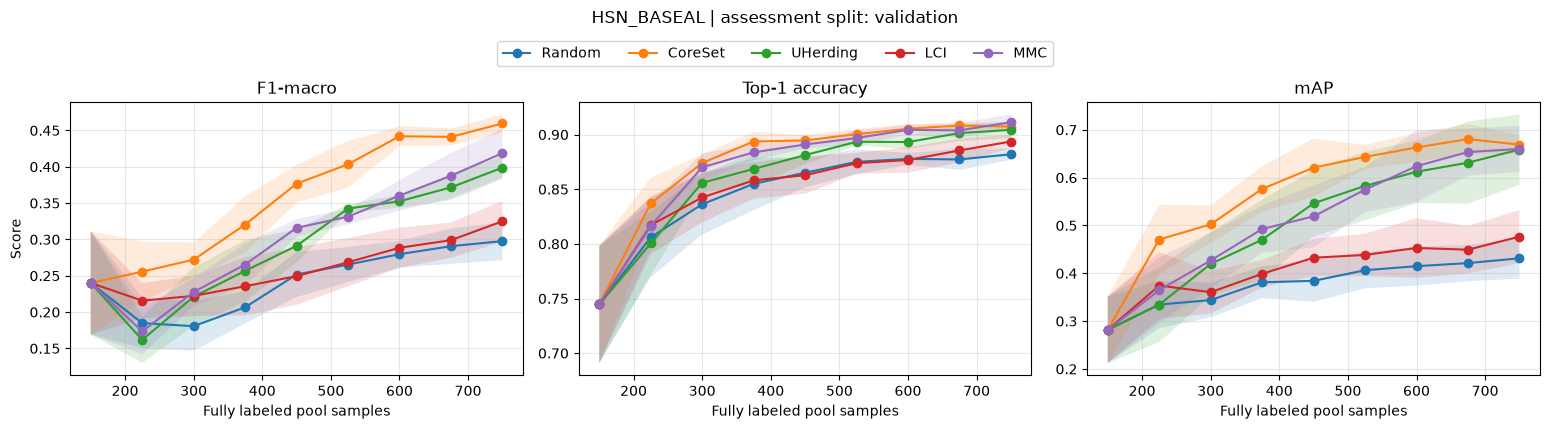

In [9]:
def plot_results(results, dataset):
    """Plot mean learning curves with one standard deviation per strategy."""
    metric_names = list(METRIC_FUNCS)
    fig, axes = plt.subplots(
        1,
        len(metric_names),
        figsize=(5.2 * len(metric_names), 4.0),
        sharex=True,
        tight_layout=True,
    )
    axes = np.atleast_1d(axes)

    for ax_idx, (ax, metric_name) in enumerate(zip(axes, metric_names)):
        for strategy_name, runs in results.items():
            budgets = np.mean([run["labeled_counts"] for run in runs], axis=0)
            curves = np.asarray(
                [run["metrics"][metric_name] for run in runs], dtype=float
            )
            mean_curve, std_curve = curves.mean(axis=0), curves.std(axis=0)
            ax.plot(
                budgets,
                mean_curve,
                marker="o",
                label=strategy_name if ax_idx == 0 else None,
            )
            if len(runs) > 1:
                ax.fill_between(
                    budgets,
                    mean_curve - std_curve,
                    mean_curve + std_curve,
                    alpha=0.15,
                )

        ax.set_title(metric_name)
        ax.set_xlabel("Fully labeled pool samples")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Score")
    fig.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=len(results),
        frameon=True,
    )
    fig.suptitle(
        f"{dataset['dataset_name']} | assessment split: "
        f"{dataset['assessment_split']}",
        y=1.06,
    )
    plt.show()


plot_results(results, dataset)

## Final Metric Summary

The table below reports the scores after the last cycle, i.e. at the full
annotation budget of `INITIAL_LABELS + N_CYCLES * QUERY_BATCH_SIZE` labeled
samples.

In [10]:
def print_final_scores(results):
    """Print the mean and standard deviation of the last cycle's scores."""
    metric_names = list(METRIC_FUNCS)
    budget = INITIAL_LABELS + N_CYCLES * QUERY_BATCH_SIZE
    print(
        f"Scores at {budget} labeled samples "
        f"(mean +- std over {N_REPETITIONS} repetitions)"
    )
    print("Strategy  " + "".join(f"{name:>20}" for name in metric_names))
    for strategy_name, runs in results.items():
        cells = []
        for metric_name in metric_names:
            finals = [run["metrics"][metric_name][-1] for run in runs]
            cells.append(f"{np.mean(finals):.3f} +- {np.std(finals):.3f}")
        print(f"{strategy_name:<10}" + "".join(f"{c:>20}" for c in cells))


print_final_scores(results)

Scores at 750 labeled samples (mean +- std over 5 repetitions)
Strategy              F1-macro      Top-1 accuracy                 mAP
Random          0.298 +- 0.026      0.882 +- 0.005      0.431 +- 0.043
CoreSet         0.460 +- 0.012      0.907 +- 0.004      0.669 +- 0.020
UHerding        0.399 +- 0.016      0.904 +- 0.008      0.659 +- 0.073
LCI             0.325 +- 0.028      0.894 +- 0.006      0.477 +- 0.056
MMC             0.419 +- 0.034      0.911 +- 0.007      0.660 +- 0.048


## What to Try Next

- Swap `DATASET_NAME` to `POW_BASEAL` or `UHH_BASEAL` to see how the ranking
  of the strategies changes with the label distribution of another pool.
- Change `SELECTED_STRATEGIES` or add further multilabel-capable strategies
  from the
  [strategy overview](https://scikit-activeml.github.io/latest/generated/strategy_overview.html).
- Raise `N_CYCLES` or `QUERY_BATCH_SIZE` to study a larger annotation budget,
  and `MAX_CANDIDATES` to trade runtime against candidate coverage.